In [1]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="Simple-v1",
    total_episodes=100_000,
    save_skip=100,
    n_runs=1,
    seed=123,
    
    use_lr_decay=True,
    decay_rate=None,
    learning_rate=1.0,

    gamma=1.0,
    epsilon=1.0,
    huber_k=0.0,
    n_quantiles=256,
    
    action_size=None,
    state_size=None,
    map_size=None,
)
rng = np.random.default_rng(params.seed)

env = gym.make(params.model_name)
env.action_space.seed(params.seed);
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)

In [68]:
learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables_run = run_env(env, learner, explorer, params, show_progress=False)
# save_experiment(tables_run, params)

Run 0/1 - Episodes: 100%|██████████| 1000000/1000000 [03:03<00:00, 5440.67it/s]


In [ ]:
params, tables_run = load_experiment("Simple-v1_prime")

In [69]:
tables = tables_run.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

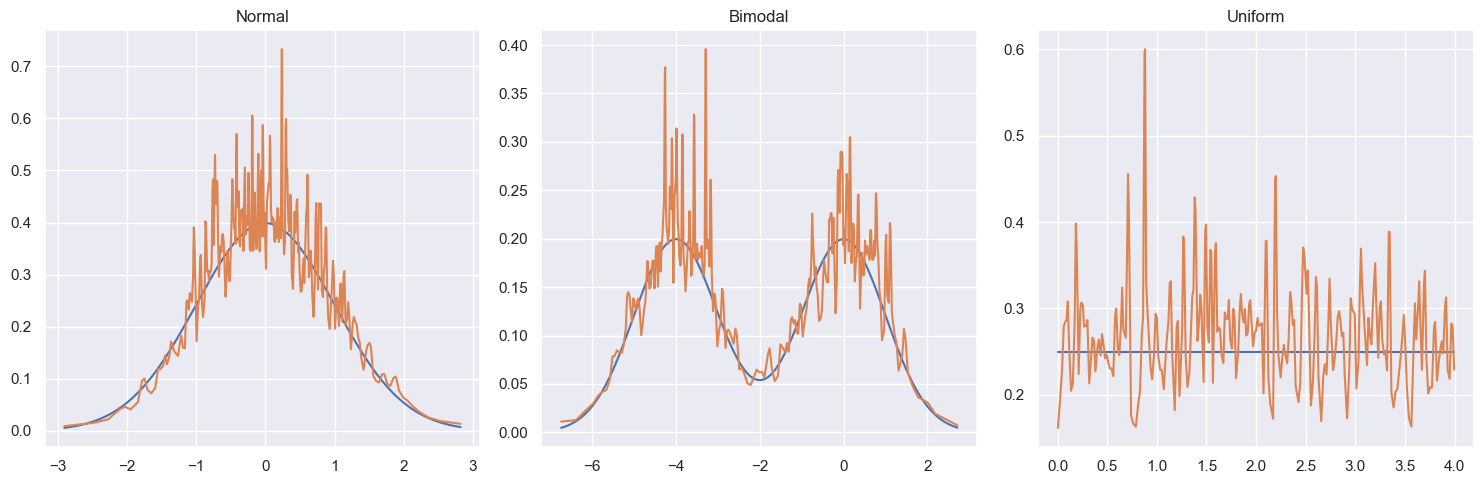

In [70]:
from analysis import plot_grad
from matplotlib import pyplot as plt
import scipy.stats as stats
import numpy as np

quantiles = tables[-1, 4]

plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
q = quantiles[0:1]
x = np.linspace(q.min(), q.max(), 1000)
y = stats.norm.pdf(x, 0, 1)
plt.plot(x, y)
plot_grad(q, params, is_filled=False)
plt.gca().get_legend().remove()
plt.title("Normal")

plt.subplot(1, 3, 2)
q = quantiles[1:2]
x = np.linspace(q.min(), q.max(), 1000)
y = 0.5 * stats.norm.pdf(x, -4, 1) + 0.5 * stats.norm.pdf(x, 0, 1)
plt.plot(x, y)
plot_grad(q, params, is_filled=False)
plt.gca().get_legend().remove()
plt.title("Bimodal")

plt.subplot(1, 3, 3)
q = quantiles[2:3]
x = np.linspace(q.min(), q.max(), 1000)
y = np.where((x >= 0) & (x <= 4), 0.25, 0)
plt.plot(x, y)
plot_grad(q, params, is_filled=False)
plt.gca().get_legend().remove()
plt.title("Uniform")

plt.tight_layout()
plt.show()

In [20]:
from tqdm import tqdm

env = gym.make(params.model_name)
total_rewards = []

for episode in tqdm(range(200_000)):
    state, _ = env.reset()
    done = False
    total_reward = 0
    discount = 1.0

    while not done:
        action = np.random.randint(0, params.action_size)
        next_state, reward, terminated, truncated, _ = env.step(action)

        total_reward += discount * reward
        discount *= params.gamma

        state = next_state
        done = terminated or truncated

    total_rewards.append(total_reward)
total_rewards.sort()
total_rewards = np.array(total_rewards)

100%|██████████| 200000/200000 [00:01<00:00, 177167.94it/s]


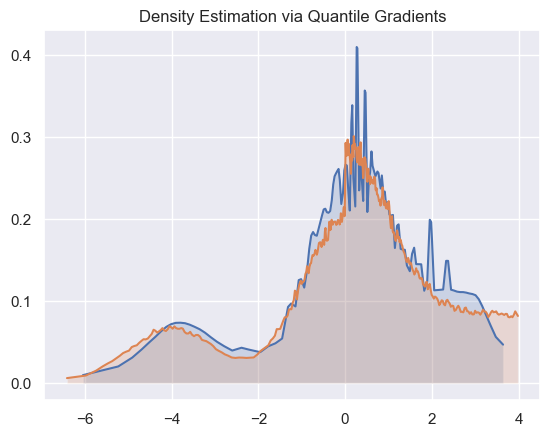

In [37]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

arrow_directions = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def plot_grad(quantiles, is_filled=True):
    r = quantiles.reshape(-1)
    r.sort()
    tau = (np.arange(len(r)) + 0.5) / len(r)
    plt.plot(r, np.gradient(tau, r))
    if is_filled:
        plt.fill_between(r, np.gradient(tau, r), alpha=0.2)
    plt.title("Density Estimation via Quantile Gradients")


r = quantiles.reshape(-1)
r.sort()
tau = (np.arange(len(r)) + 0.5) / len(r)
# plt.hist(r, bins=80);
plot_grad(r[::3][::1])
plot_grad(total_rewards[(tau*len(total_rewards)).round().astype(int)][::1])

# plt.plot(total_rewards[(tau*len(total_rewards)).round().astype(int)]);

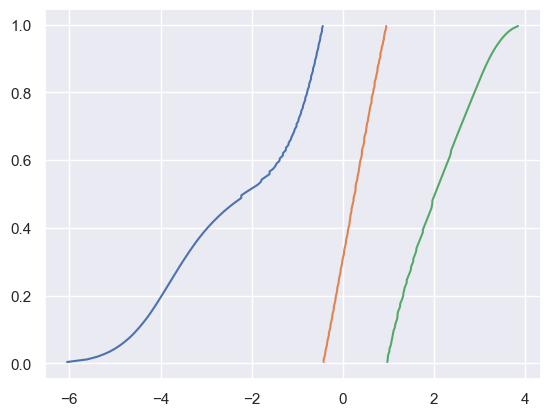

In [47]:
for q in quantiles:
    tau = (np.arange(len(q)) + 0.5) / len(q)
    plt.plot(q, tau)